# Instalación de dependencias

In [11]:
!pip install opencv-python-headless matplotlib ultralytics --quiet

# Importaciones

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import files
from IPython.display import display

# Carpeta de resultados
os.makedirs("resultados", exist_ok=True)

# Subida de Imagen

Selecciona una imagen desde tu ordenador (JPG, PNG, etc.):


Saving Evangelion-25-aniversario-900x491.jpg to Evangelion-25-aniversario-900x491 (1).jpg
Imagen cargada: Evangelion-25-aniversario-900x491 (1).jpg  |  Resolución: 900×491 px


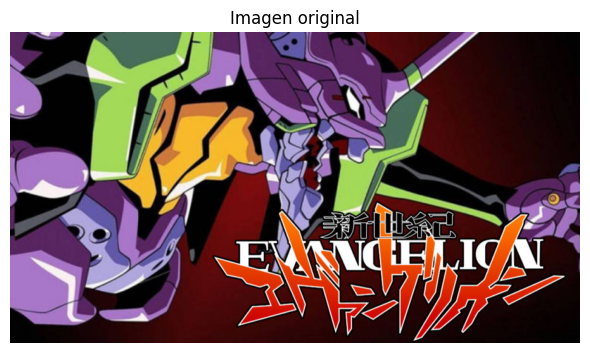

In [13]:
print("Selecciona una imagen desde tu ordenador (JPG, PNG, etc.):")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
img_array = np.frombuffer(uploaded[filename], dtype=np.uint8)
img_bgr = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

if img_bgr is None:
    raise ValueError("No se pudo decodificar la imagen. Verifica que el archivo sea una imagen válida.")

print(f"Imagen cargada: {filename}  |  Resolución: {img_bgr.shape[1]}×{img_bgr.shape[0]} px")

# Convertir a RGB para visualizar correctamente con matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Guardar original
cv2.imwrite("resultados/original.png", img_bgr)

plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.title("Imagen original")
plt.axis("off")
plt.tight_layout()
plt.savefig("resultados/original_preview.png", dpi=120)
plt.show()

# PASO 1: Escala de grises

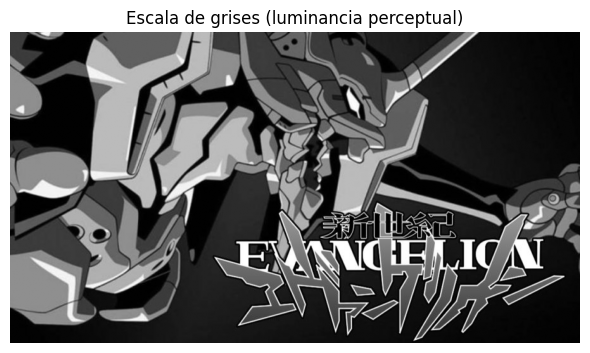

Paso 1 completado — escala de grises guardada.


In [14]:
"""
DECISIÓN TÉCNICA:
  cv2.COLOR_BGR2GRAY usa la fórmula ponderada perceptual:
  Y = 0.299·R + 0.587·G + 0.114·B
  Esto respeta la sensibilidad del ojo humano a cada canal,
  produciendo una representación de luminancia más natural
  que un promedio simple de los tres canales.
"""
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
cv2.imwrite("resultados/grises.png", gray)

plt.figure(figsize=(6, 4))
plt.imshow(gray, cmap="gray")
plt.title("Escala de grises (luminancia perceptual)")
plt.axis("off")
plt.tight_layout()
plt.savefig("resultados/grises_preview.png", dpi=120)
plt.show()
print("Paso 1 completado — escala de grises guardada.")

# PASO 2: Espacio de color HSV

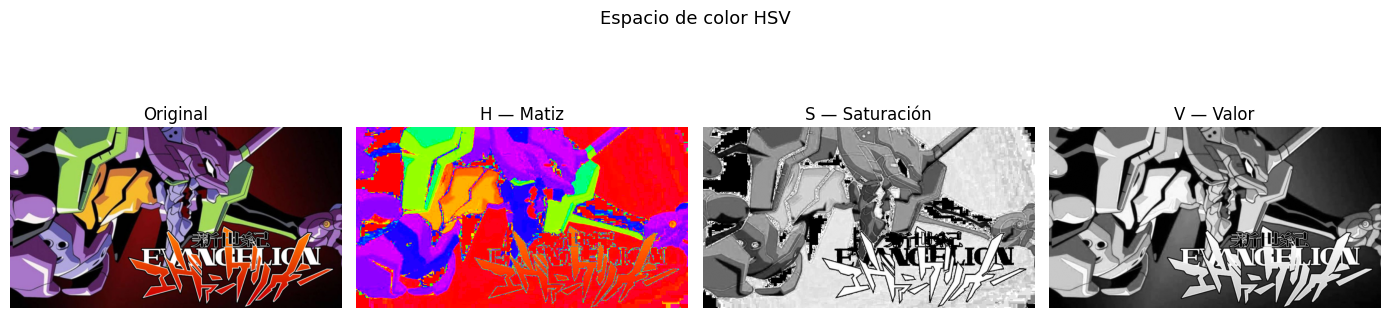

Paso 2 completado — imagen HSV guardada.


In [15]:
"""
DECISIÓN TÉCNICA:
  Se eligió HSV (Hue–Saturation–Value) sobre LAB porque:
  - Separa el matiz (tono de color) de la intensidad lumínica,
    lo que facilita la segmentación basada en color en pasos posteriores.
  - Es ampliamente usado en visión por computador para detección
    de objetos de color específico bajo distintas iluminaciones.
  - El canal H (0–179 en OpenCV) permite crear máscaras de color
    con rangos intuitivos.
"""
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
cv2.imwrite("resultados/hsv.png", hsv)

# Visualizar los tres canales por separado
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(img_rgb);               axes[0].set_title("Original");    axes[0].axis("off")
axes[1].imshow(hsv[:,:,0], cmap="hsv"); axes[1].set_title("H — Matiz");   axes[1].axis("off")
axes[2].imshow(hsv[:,:,1], cmap="gray");axes[2].set_title("S — Saturación"); axes[2].axis("off")
axes[3].imshow(hsv[:,:,2], cmap="gray");axes[3].set_title("V — Valor");   axes[3].axis("off")
plt.suptitle("Espacio de color HSV", fontsize=13)
plt.tight_layout()
plt.savefig("resultados/hsv_preview.png", dpi=120)
plt.show()
print("Paso 2 completado — imagen HSV guardada.")

# PASO 3: Suavizado Gaussiano

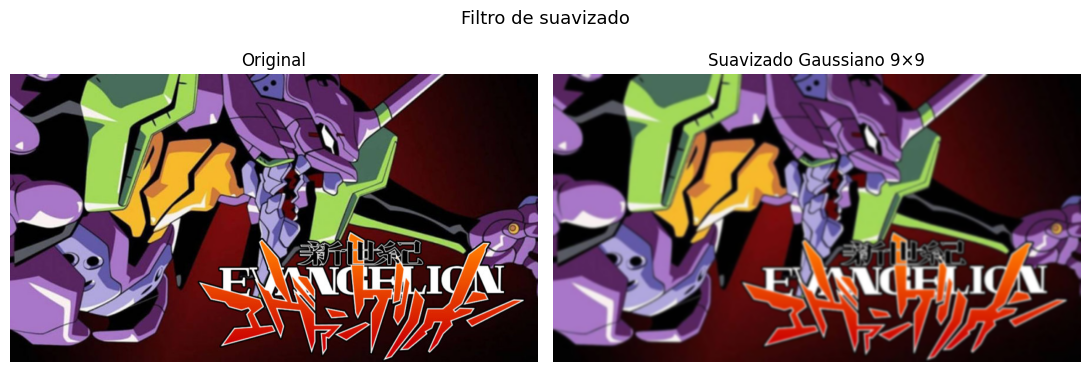

Paso 3 completado — imagen suavizada guardada.


In [16]:
"""
DECISIÓN TÉCNICA:
  Filtro Gaussiano con kernel 9×9 y σ=0 (calculado automáticamente ≈3).
  - El kernel impar 9×9 aplica un suavizado moderado sin destruir
    estructuras medianas; un kernel 3×3 sería insuficiente y un 15×15
    eliminaría bordes importantes.
  - σ automático: OpenCV lo calcula como σ = 0.3·((k−1)·0.5−1)+0.8,
    garantizando coherencia entre tamaño de kernel y desvío estándar.
  - Se prefirió Gaussiano sobre Mediana porque la imagen no fue
    contaminada con ruido sal-pimienta, sino que necesita un suavizado
    genérico previo a la detección de bordes.
"""
kernel_size = (9, 9)
blurred = cv2.GaussianBlur(img_bgr, kernel_size, sigmaX=0)
cv2.imwrite("resultados/suavizado.png", blurred)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img_rgb);                             axes[0].set_title("Original");                        axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)); axes[1].set_title("Suavizado Gaussiano 9×9"); axes[1].axis("off")
plt.suptitle("Filtro de suavizado", fontsize=13)
plt.tight_layout()
plt.savefig("resultados/suavizado_preview.png", dpi=120)
plt.show()
print("Paso 3 completado — imagen suavizada guardada.")

# PASO 4: Detección de bordes (Canny)

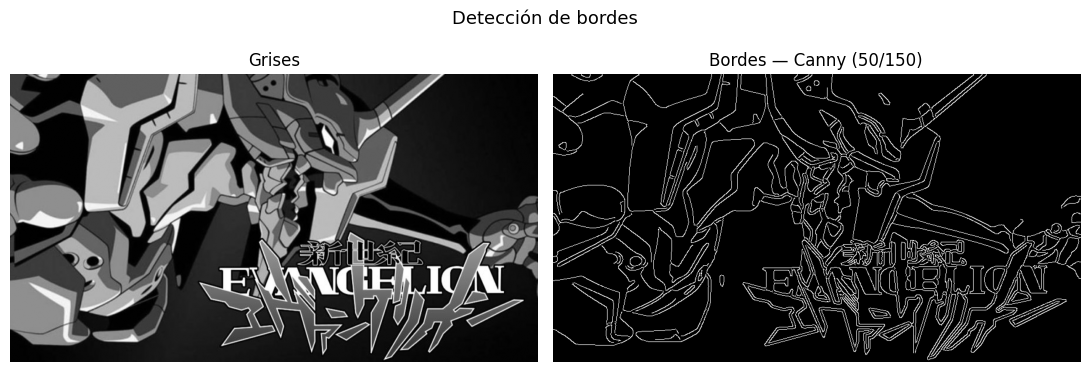

Paso 4 completado — bordes guardados.


In [17]:
"""
DECISIÓN TÉCNICA:
  Algoritmo de Canny con umbrales bajo=50 y alto=150.
  - Canny aplica internamente: suavizado Gaussiano → gradiente Sobel →
    supresión de no-máximos → histéresis por doble umbral.
  - La relación 1:3 (50–150) es la recomendada por Canny en su paper
    original; detecta bordes fuertes y conecta bordes débiles adyacentes.
  - Se aplica sobre la imagen en grises ya suavizada para reducir
    bordes espurios generados por ruido de textura.
  - Alternativa Sobel: genera bordes más "gruesos" y requiere un paso
    extra de umbralización; Canny produce bordes más limpios y delgados.
"""
gray_blurred = cv2.GaussianBlur(gray, (9, 9), 0)
edges = cv2.Canny(gray_blurred, threshold1=50, threshold2=150)
cv2.imwrite("resultados/bordes.png", edges)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(gray, cmap="gray");  axes[0].set_title("Grises"); axes[0].axis("off")
axes[1].imshow(edges, cmap="gray"); axes[1].set_title("Bordes — Canny (50/150)"); axes[1].axis("off")
plt.suptitle("Detección de bordes", fontsize=13)
plt.tight_layout()
plt.savefig("resultados/bordes_preview.png", dpi=120)
plt.show()
print("Paso 4 completado — bordes guardados.")

# PASO 5: Segmentación por color (técnica clásica HSV)

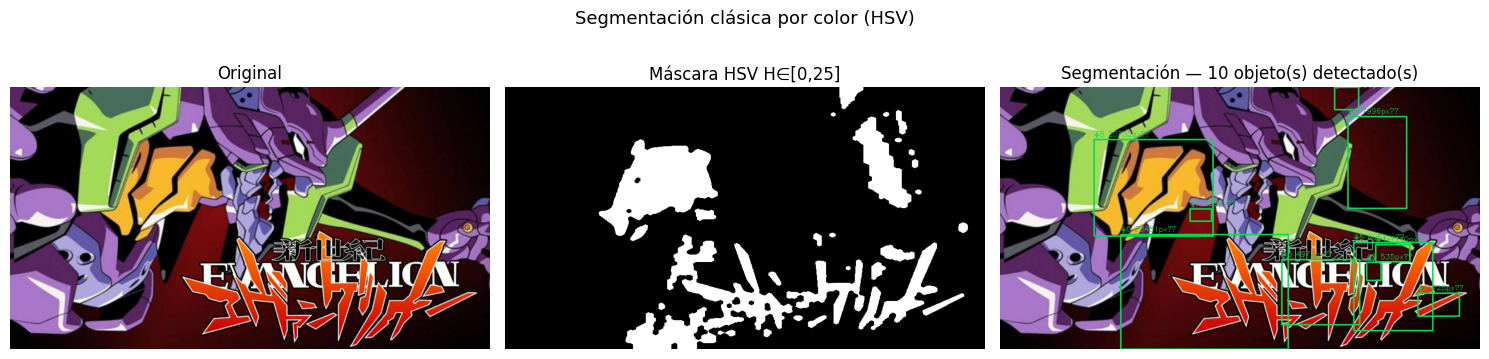

Paso 5 completado — 10 objeto(s) detectado(s). Resultados guardados.


In [18]:
"""
DECISIÓN TÉCNICA:
  Segmentación clásica por rango de color en espacio HSV.

  Estrategia:
  1. Se detecta automáticamente el color dominante del histograma H
     para crear un rango centrado en ese matiz (±25 grados).
  2. Se aplica una máscara binaria con cv2.inRange() sobre el canal H.
  3. Se limpian artefactos con operaciones morfológicas (apertura +
     cierre con kernel 5×5).
  4. Se extraen contornos externos con cv2.findContours() y se dibuja
     un bounding box sobre los objetos detectados (área > 500 px²).

  Por qué clásica y no un modelo preentrenado:
  - La segmentación por color es interpretable, rápida y reproducible
    sin GPU ni dependencias externas en Colab.
  - Se eligió HSV sobre RGB porque en RGB los rangos de color varían
    drásticamente con la iluminación, mientras que H es más estable.
  - La apertura morfológica (erosión + dilatación) elimina píxeles
    aislados de ruido; el cierre morfológico (dilatación + erosión)
    rellena huecos en la máscara.
"""

# ── Detectar matiz dominante automáticamente ──────────────────
h_channel = hsv[:, :, 0]
hist_h = cv2.calcHist([h_channel], [0], None, [180], [0, 180])
dominant_h = int(np.argmax(hist_h))

# Rango de ±25 en H, S > 40, V > 40 (excluir negros y blancos)
h_low  = max(0,   dominant_h - 25)
h_high = min(179, dominant_h + 25)
lower = np.array([h_low,  40,  40])
upper = np.array([h_high, 255, 255])

mask = cv2.inRange(hsv, lower, upper)

# ── Limpieza morfológica ───────────────────────────────────────
kernel_morph = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel_morph, iterations=2)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_morph, iterations=2)

# ── Extraer contornos y dibujar bounding boxes ────────────────
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result = img_rgb.copy()
n_detected = 0
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 500:           # filtrar ruido pequeño
        continue
    n_detected += 1
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(result, (x, y), (x+w, y+h), (0, 220, 80), 2)
    cv2.putText(result, f"#{n_detected} {int(area)}px²",
                (x, max(y - 6, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 220, 80), 1)

cv2.imwrite("resultados/segmentacion.png", cv2.cvtColor(result, cv2.COLOR_RGB2BGR))
cv2.imwrite("resultados/mascara.png", mask)

# ── Visualización comparativa ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img_rgb);  axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title(f"Máscara HSV H∈[{h_low},{h_high}]"); axes[1].axis("off")
axes[2].imshow(result)
axes[2].set_title(f"Segmentación — {n_detected} objeto(s) detectado(s)"); axes[2].axis("off")
plt.suptitle("Segmentación clásica por color (HSV)", fontsize=13)
plt.tight_layout()
plt.savefig("resultados/segmentacion_preview.png", dpi=120)
plt.show()
print(f"Paso 5 completado — {n_detected} objeto(s) detectado(s). Resultados guardados.")

# PASO 6: Panel comparativo final (todas las etapas)

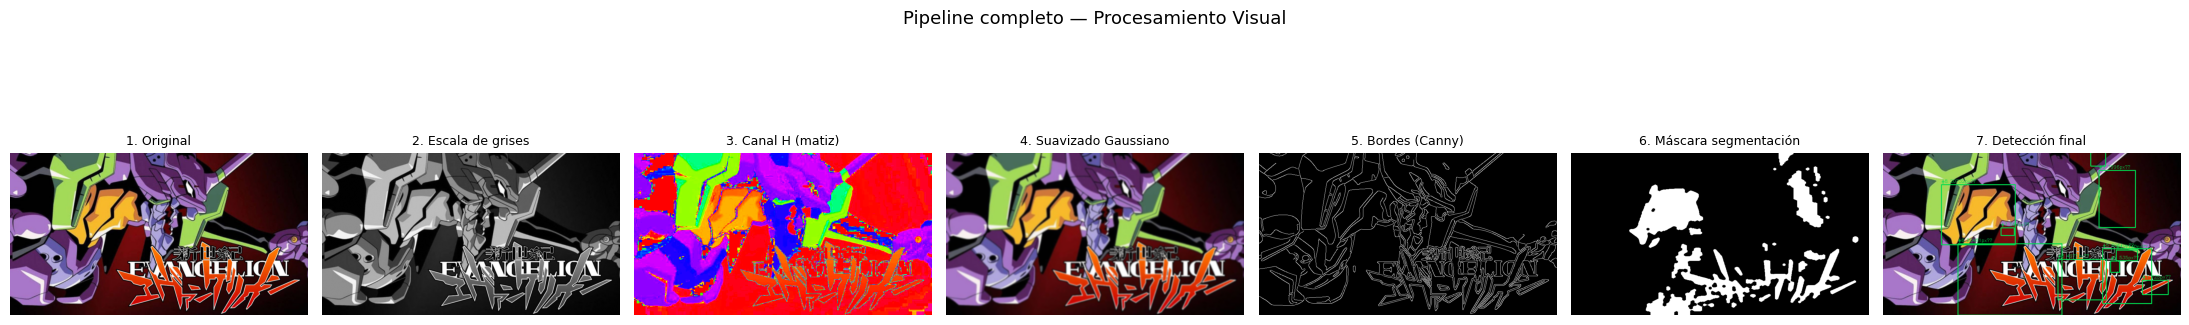

Panel comparativo guardado en resultados/pipeline_completo.png


In [19]:
etapas = [
    (img_rgb,                              "1. Original",             None),
    (gray,                                 "2. Escala de grises",     "gray"),
    (hsv[:,:,0],                           "3. Canal H (matiz)",      "hsv"),
    (cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB), "4. Suavizado Gaussiano", None),
    (edges,                                "5. Bordes (Canny)",       "gray"),
    (mask,                                 "6. Máscara segmentación", "gray"),
    (result,                               "7. Detección final",      None),
]

fig, axes = plt.subplots(1, len(etapas), figsize=(22, 4))
for ax, (img_data, titulo, cmap) in zip(axes, etapas):
    ax.imshow(img_data, cmap=cmap)
    ax.set_title(titulo, fontsize=9)
    ax.axis("off")

plt.suptitle("Pipeline completo — Procesamiento Visual", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("resultados/pipeline_completo.png", dpi=130, bbox_inches="tight")
plt.show()
print("Panel comparativo guardado en resultados/pipeline_completo.png")

# Descarga de todos los resultados como ZIP

In [20]:
import shutil
shutil.make_archive("resultados_ejercicio1", "zip", "resultados")
files.download("resultados_ejercicio1.zip")
print("ZIP descargado con todos los resultados.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ZIP descargado con todos los resultados.
